# 01. K-means 알고리즘

## k-means 이용 iris dataset clustering

In [3]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
irisDF = pd.DataFrame(data=iris.data,columns=['sepal_length','sepal_width','petal_length','petal_width'])
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


- k-means.fit(데이터셋)

In [4]:
kmeans = KMeans(n_clusters=3, init='k-means++',max_iter=300,random_state=0)
kmeans.fit(irisDF)

KMeans(n_clusters=3, random_state=0)

### kmeans객체.labels_
각 데이터가 어떤 중심에 속하는지 알 수 있음.

In [6]:
print(kmeans.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [9]:
# irisDF에 target, cluster 열 추가
irisDF['target']=iris.target
irisDF['cluster']=kmeans.labels_
# target,cluster 그룹화 후 sepal_length 기준으로 count하기
iris_result = irisDF.groupby(['target','cluster'])['sepal_length'].count()
print(iris_result);

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64


- PCA로 차원 축소 ( 4개 속성 > 2개 속성 )
- x좌표 : pca_x, y좌표 : pca_y

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(iris.data)

irisDF['pca_x'] = pca_transformed[:,0]
irisDF['pca_y'] = pca_transformed[:,1]
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,-2.888991,-0.144949


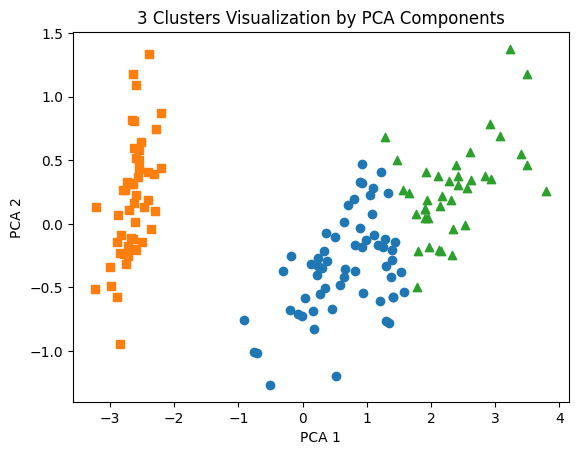

In [12]:
# 군집 값이 0,1,2인 경우마다 별도의 인덱스로 추출
marker0_ind = irisDF[irisDF['cluster']==0].index
marker1_ind = irisDF[irisDF['cluster']==1].index
marker2_ind = irisDF[irisDF['cluster']==2].index

# 군집 값 0,1,2에 해당하는 인덱스로 각 군집의 pca_x,pca_y 추출, o,s,^ 표시
plt.scatter(x=irisDF.loc[marker0_ind,'pca_x'],y=irisDF.loc[marker0_ind,'pca_y'],marker='o')
plt.scatter(x=irisDF.loc[marker1_ind,'pca_x'],y=irisDF.loc[marker1_ind,'pca_y'],marker='s')
plt.scatter(x=irisDF.loc[marker2_ind,'pca_x'],y=irisDF.loc[marker2_ind,'pca_y'],marker='^')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('3 Clusters Visualization by PCA Components')
plt.show()

- cluster 1(⏹) : 군집이 잘 분리됨
- cluster 0(⚫), cluster 2(▲) : 상당히 분리돼있지만 1 보다는 아님. 데이터 위치상 명확히 분리되기 어려움.

## 군집화 알고리즘 테스트를 위한 데이터 생성
from sklearn.datasets
- make_circle(), make_moon() : centroid 기반 군집화로 해결하기 어려운 데이터셋 만드는데 사용됨
- make_classification() : 노이즈 포함 가능
- make_blobs() : 개별 군집의 centroid와 표준 편차 제어 가능

#### ▶    make_blobs()의 파라미터

*   n_samples : 생성할 데이터 수 ( default : 100 )
*   n_features : 데이터의 피처 수 ( 시각화 - 2개 )
*   center - k개의 개수(int), centroid의 좌표(ndarray)
*   cluster_std : 생성될 군집 데이터의 표준 편차, 데이터의 분포도 조절

 작을수록 군집 중심에 데이터가 모여있고 클수록 퍼져있음.

  군집별로 서로 다른 표준편차 지정 시 list 형태

  ex) [0.8,1.2,0.6] > 0번째 군집내 표준 편차 0.8, 1번째는 1.2, 2번째는 0.6






In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
%matplotlib inline

# 200개 데이터, 2개의 피처가
## 3개의 군집화 기반 분포도를 가진 피처데이터 셋 X
## 3개의 군집화 값을 가진 타깃 데이터셋 y 반환
X,y = make_blobs(n_samples=200, n_features=2, centers = 3, cluster_std=0.8,
                 random_state=0)

print(X.shape,y.shape)

# y target 값의 분포 확인
unique,counts = np.unique(y,return_counts=True)
print(unique,counts)

(200, 2) (200,)
[0 1 2] [67 67 66]


feature dataset > (200,2)

y shape > (200,1)

cluster 값 > [0,1,2]

각각 [67,67,66]으로 균일하게 구성됨

In [19]:
import pandas as pd
# DataFrame을 변환, 열 : 1번피처(ftr1), 2번 피처(ftr2), target값(속한 군집 넘버)
clusterDF = pd.DataFrame(data=X,columns=['ftr1','ftr2'])
clusterDF['target']=y
clusterDF.head(3)

,ftr1,ftr2,target
0,-1.692427,3.622025,2
1,0.697940,4.428867,0
2,1.100228,4.606317,0


* 데이터 scatter plot _ target 별로 marker, 색 구분

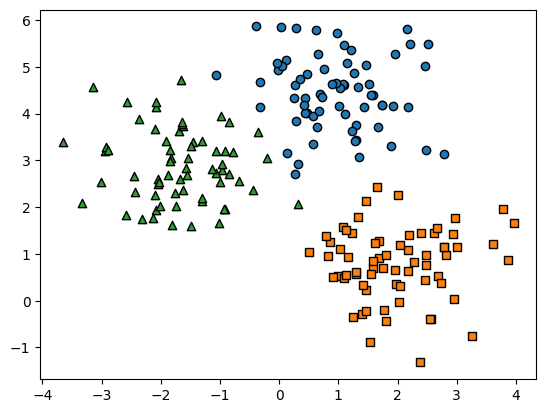

In [22]:
target_list = np.unique(y)
# 산점도의 타깃 별 마커값
markers = ['o','s','^','P','D','H','x']
# k = 3 > target_list = [0,1,2]
# target = 0, target = 1, target = 2로 marker 구분 / scatter plot 생성
for target in target_list:
  target_cluster = clusterDF[clusterDF['target']==target]
  plt.scatter(x=target_cluster['ftr1'],y=target_cluster['ftr2'],edgecolors='k',
              marker=markers[target])
plt.show()

* 만들어진 데이터셋에 KMeans clustering 수행 > 시각화
* fit_predict(X)

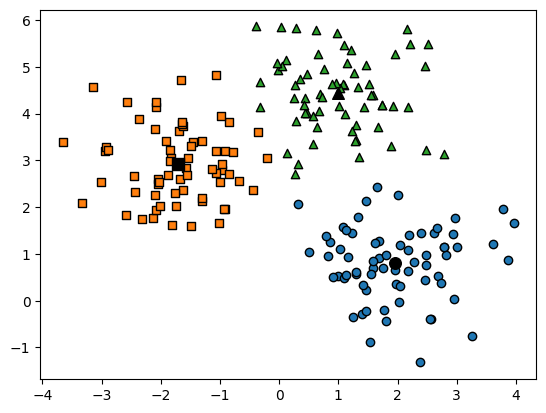

In [26]:
# k-means clustering 수행
kmeans = KMeans(n_clusters=3, init='k-means++',max_iter=200,random_state=0)
cluster_labels = kmeans.fit_predict(X)
clusterDF['kmeans_label'] = cluster_labels

# cluster_cennters_를 시각화를 위해 추출
centers = kmeans.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers = ['o','s','^','P','D','H','x']

# 군집된 label 유형별 iteration, marker별 scatterplot
for label in unique_labels:
  label_cluster = clusterDF[clusterDF['kmeans_label']==label]
  center_x_y = centers[label]
  plt.scatter(x=label_cluster['ftr1'],y=label_cluster['ftr2'],edgecolors='k',
              marker=markers[label])

  # k별 centroid 위치 시각화
  plt.scatter(x=center_x_y[0],y=center_x_y[1],s=70,color='k',edgecolors='k',
              marker=markers[label])
plt.show()

In [28]:
print(clusterDF.groupby('target')['kmeans_label'].value_counts())

target  kmeans_label
0       2               66
        1                1
1       0               67
2       1               65
        0                1
Name: count, dtype: int64


# 02. 군집 평가(Cluster Evaluation)

## 붓꽃 데이터 세트를 이용한 군집 평가

In [31]:
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
feature_names=['sepal_length','sepal_width','petal_length','petal_width']
irisDF = pd.DataFrame(data=iris.data,columns=feature_names)
kmeans = KMeans(n_clusters=3,init='k-means++',max_iter=300,random_state=0).fit(irisDF)
irisDF['cluster']=kmeans.labels_

# 각 데이터에 실루엣 계수값 구하기
score_samples = silhouette_samples(iris.data,irisDF['cluster'])
print('silhouette_samples returne 값의 shape : ',score_samples.shape)

# irisDF에 silhouette 계수 칼럼 추가
irisDF['silhouette_coeff']=score_samples

# 모든 데이터의 평균 실루엣 계수값
average_score = silhouette_score(iris.data,irisDF['cluster'])
print('붓꽃 데이터셋 Silhouette Analysis Score: {0:.3f}'.format(average_score))
irisDF.head(3)

silhouette_samples returne 값의 shape :  (150,)
붓꽃 데이터셋 Silhouette Analysis Score: 0.551


,sepal_length,sepal_width,petal_length,petal_width,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,1,0.852582
1,4.9,3.0,1.4,0.2,1,0.814916
2,4.7,3.2,1.3,0.2,1,0.828797


In [32]:
# 군집별 평균 실루엣 계수값 확인
irisDF.groupby('cluster')['silhouette_coeff'].mean()

,silhouette_coeff
cluster,
0,0.422323
1,0.797604
2,0.436842


## 군집별 평균 실루엣 계수의 시각화를 통한 군집 개수 최적화 방법

* 평균 실루엣 계수값 🔼라고 군집화 잘됐다고 볼 수 없음.
* 실루엣계수값의 편차(개별 평균 - 전체 평균)가 작아야 함.

#### visualize_silhouette() 함수
군집 개수를 변화시키면서 k-means 수행했을 때 개별 군비별 평균 실루엣계수값 시각화 -> k 정하는데 도움

In [33]:
### 여러개의 클러스터링 갯수를 List로 입력 받아 각각의 실루엣 계수를 면적으로 시각화한 함수 작성
def visualize_silhouette(cluster_lists, X_features):

    from sklearn.datasets import make_blobs
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import math

    # 입력값으로 클러스터링 갯수들을 리스트로 받아서, 각 갯수별로 클러스터링을 적용하고 실루엣 개수를 구함
    n_cols = len(cluster_lists)

    # plt.subplots()으로 리스트에 기재된 클러스터링 수만큼의 sub figures를 가지는 axs 생성
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)

    # 리스트에 기재된 클러스터링 갯수들을 차례로 iteration 수행하면서 실루엣 개수 시각화
    for ind, n_cluster in enumerate(cluster_lists):

        # KMeans 클러스터링 수행하고, 실루엣 스코어와 개별 데이터의 실루엣 값 계산.
        clusterer = KMeans(n_clusters = n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)

        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)

        y_lower = 10
        axs[ind].set_title('Number of Cluster : '+ str(n_cluster)+'\n' \
                          'Silhouette Score :' + str(round(sil_avg,3)) )
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the yaxis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        # 클러스터링 갯수별로 fill_betweenx( )형태의 막대 그래프 표현.
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels==i]
            ith_cluster_sil_values.sort()

            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values, \
                                facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

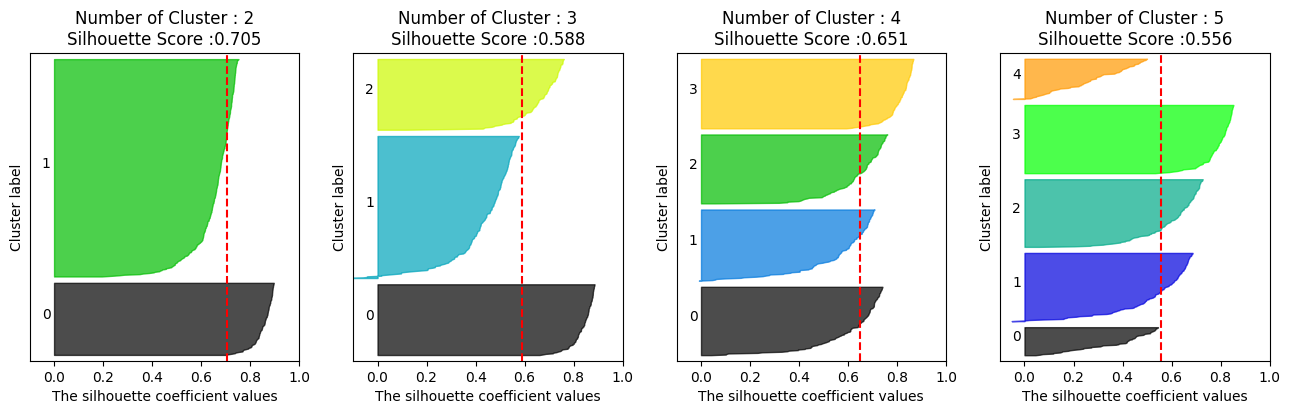

In [35]:
from sklearn.datasets import make_blobs
X,y = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=1,
                 center_box=(-10.0,10.0), shuffle=True, random_state=1)
# 군집 개수 2,3,4,5 일 때 군집별 실루엣 계수 평균값 시각화
visualize_silhouette([2,3,4,5],X)

* k = 4일 때 개별 군집별 평균 실루엣 계수 유사, 전체 실루엣 계수 평균 0.651로 2번째로 높음.

  ▶ 가장 적합.

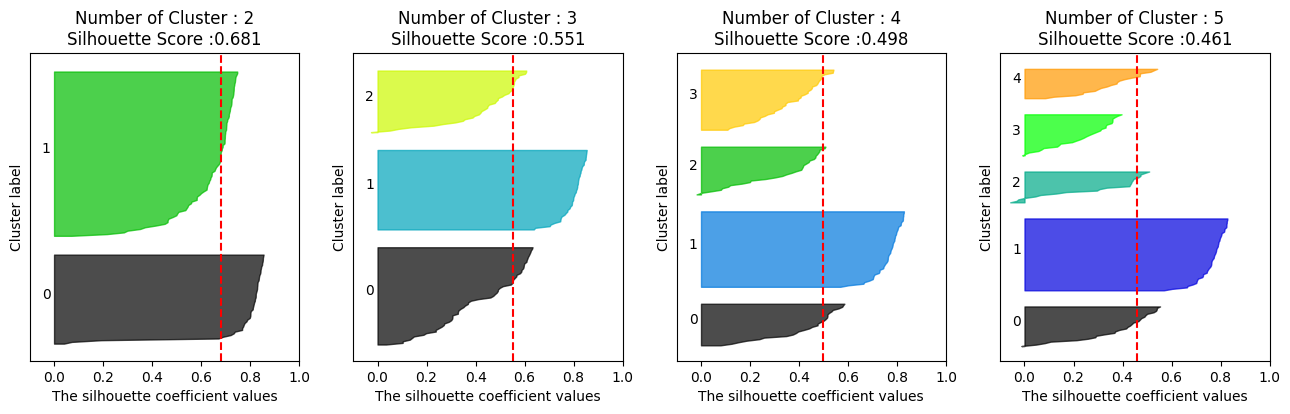

In [36]:
from sklearn.datasets import load_iris
iris=load_iris()
visualize_silhouette([2,3,4,5],iris.data)

* k = 2일 때 개별 군집별 평균 실루엣 계수 유사, 전체 실루엣 계수 평균 제일 높음.

  ▶ 가장 적합.

# 03. 평균 이동( Mean Shift )

- make_blobs() : cluster_std = 0.7, k=3
- bandwidth = 0.8

In [37]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift

X,y = make_blobs(n_samples=200, n_features=2, centers=3,
                 cluster_std=0.7, random_state=0)
meanshift=MeanShift(bandwidth=0.8)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형 : ',np.unique(cluster_labels))

cluster labels 유형 :  [0 1 2 3 4 5]


⬆ 군집이 0~5, 총 6개로 분류됨 -> overfitting ( h가 너무 작았음 )

In [38]:
meanshift=MeanShift(bandwidth=1)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형 : ',np.unique(cluster_labels))

cluster labels 유형 :  [0 1 2]


⬆ 3개로 잘 군집화됨.

⬇ estimate_bandwidth() 사용

In [39]:
from sklearn.cluster import estimate_bandwidth

bandwidth = estimate_bandwidth(X)
print('bandwidth 값:',round(bandwidth,3))

bandwidth 값: 1.816


- estimate_bandwidth()로 측정된 최적의 bandwidth값으로 평균이동 수행

In [40]:
import pandas as pd

clusterDF = pd.DataFrame(data=X,columns=['ftr1','ftr2'])
clusterDF['target']=y

# estimate_bandwidth() -> optimal bandwidth
best_bandwidth = estimate_bandwidth(X)

meanshift=MeanShift(bandwidth=best_bandwidth)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형 : ',np.unique(cluster_labels))

cluster labels 유형 :  [0 1 2]


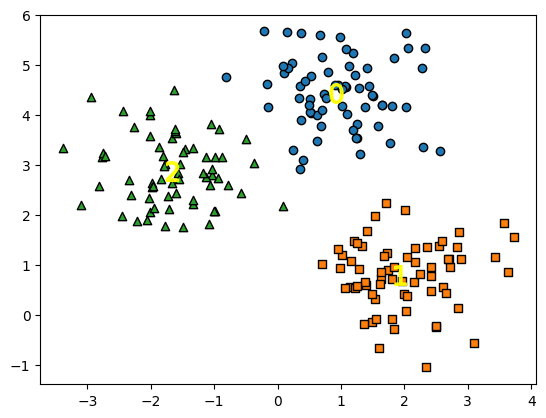

In [44]:
import matplotlib.pyplot as plt
%matplotlib inline

clusterDF['meanshift_label']=cluster_labels
centers = meanshift.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers = ['o','s','^','x','*']

for label in unique_labels:
  label_cluster = clusterDF[clusterDF['meanshift_label']==label]
  center_x_y = centers[label]
  # 산점도에 군집별로 다른 마커 표시
  plt.scatter(x=label_cluster['ftr1'],y=label_cluster['ftr2'],
              edgecolors='k',marker=markers[label])
  # centroid 군집별 표시
  plt.scatter(x=center_x_y[0],y=center_x_y[1],
              s=200,color='yellow',alpha=0.9,marker='$%d$' % label)
plt.show()

In [45]:
print(clusterDF.groupby('target')['meanshift_label'].value_counts())

target  meanshift_label
0       0                  67
1       1                  67
2       2                  66
Name: count, dtype: int64


✅ target값과 군집값이 1 : 1로 잘 매칭됨.

# 04. GMM( Gaussian Mixture Model )

## GMM을 이용한 붓꽃 데이터세트 군집화

In [46]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
feature_names = ['sepal_length','sepal_width','petal_length','petal_width']

irisDF = pd.DataFrame(data=iris.data,columns=feature_names)
irisDF['target']=iris.target

In [47]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=0).fit(iris.data)
gmm_cluster_labels = gmm.predict(iris.data)
# cluster 라벨 예측값 'gmm_cluster'에 저장
irisDF['gmm_cluster']=gmm_cluster_labels

# target 값에 따라 gmm_cluster이 어떻게 매핑됐는지 확인
iris_result = irisDF.groupby(['target'])['gmm_cluster'].value_counts()
print(iris_result)

target  gmm_cluster
0       1              50
1       0              45
        2               5
2       2              50
Name: count, dtype: int64


- Target 0, 2 > 잘 매핑됨
- Target 1 > 90%는 0으로 매핑됨, 10%는 cluster 2로 매핑됨.

In [49]:
kmeans = KMeans(n_clusters=3, init='k-means++',max_iter=300,random_state=0).fit(iris.data)
kmeans_cluster_labels = kmeans.predict(iris.data)
irisDF['kmeans_cluster']=kmeans_cluster_labels
iris_result = irisDF.groupby(['target'])['kmeans_cluster'].value_counts()
print(iris_result)

target  kmeans_cluster
0       1                 50
1       0                 47
        2                  3
2       2                 36
        0                 14
Name: count, dtype: int64


- Target 0 > cluster 1 로 100 % 매핑됨
- Target 1 > cluster 0 : 94%, cluster 2 : 6%
- Target 2 > cluster 0 : 28%, cluster 2 : 72%

▶ 붓꽃데이터 세트는 kmeans 보다 gmm 군집화에 더 적합함.

## GMM과 K-means의 비교

- cluster_std ⬇, 데이터 원형 형태로 분산

#### ✅ visualize_cluster_plot의 input값
1. clusterobj > fit() & predict()로 군집화가 완료된 객체/ None ( make_blobs()로 생성한 데이터)
2. dataframe : X(feature) + y(label) 데이터프레임
3. label_name : 군집화 label 컬럼명 / target 컬럼명
4. iscenter : cluster 객체가 cluster_centers_로 centroid 좌표 제공시 True / 그렇지 않으면 False

In [50]:
### 클러스터 결과를 담은 DataFrame과 사이킷런의 Cluster 객체등을 인자로 받아 클러스터링 결과를 시각화하는 함수
def visualize_cluster_plot(clusterobj, dataframe, label_name, iscenter=True):
    if iscenter :
        centers = clusterobj.cluster_centers_

    unique_labels = np.unique(dataframe[label_name].values)
    markers=['o', 's', '^', 'x', '*']
    isNoise=False

    for label in unique_labels:
        label_cluster = dataframe[dataframe[label_name]==label]
        if label == -1:
            cluster_legend = 'Noise'
            isNoise=True
        else :
            cluster_legend = 'Cluster '+str(label)

        plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], s=70,\
                    edgecolor='k', marker=markers[label], label=cluster_legend)

        if iscenter:
            center_x_y = centers[label]
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=250, color='white',
                        alpha=0.9, edgecolor='k', marker=markers[label])
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k',\
                        edgecolor='k', marker='$%d$' % label)
    if isNoise:
        legend_loc='upper center'
    else: legend_loc='upper right'

    plt.legend(loc=legend_loc)
    plt.show()

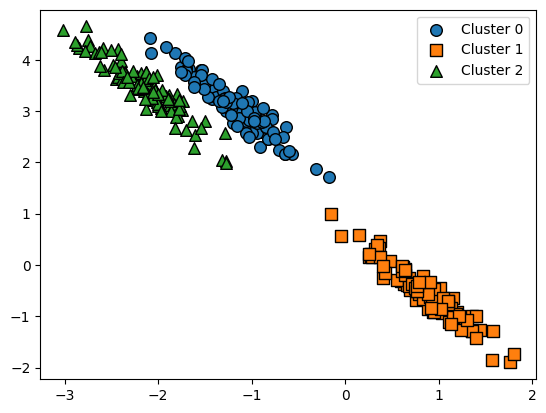

In [51]:
from sklearn.datasets import make_blobs

# 300개, feature 수 2개, 표준편차 = 0.5
X,y = make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=0.5, random_state=0)

# 길게 늘어난 타원형의 데이터 셋 생성하기 위해 변환
transformation = [[0.6083459,-0.63667341],[-0.40887718,0.85253229]]
X_aniso = np.dot(X,transformation) # 행렬곱 -> 타원형 변환
# DataFrame : feature dataset + y 결과값
clusterDF = pd.DataFrame(data = X_aniso, columns=['ftr1','ftr2'])
clusterDF['target']=y
# 생성된 dataset 시각화
visualize_cluster_plot(None, clusterDF, 'target', iscenter=False)

- 타원형 dataset > k-means 성능 🔽
- 원형으로 개별 군집화가 돼 의도한 대로 구성되지 않음.

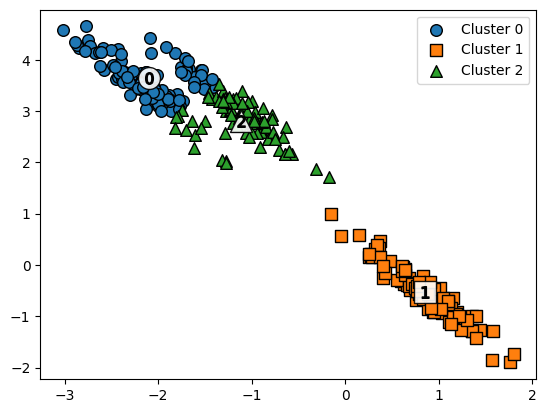

In [52]:
# kmeans : k=3
kmeans= KMeans(3,random_state=0)
kmeans_label = kmeans.fit_predict(X_aniso)
clusterDF['kmeans_label']=kmeans_label

visualize_cluster_plot(kmeans,clusterDF,'kmeans_label',iscenter=True)

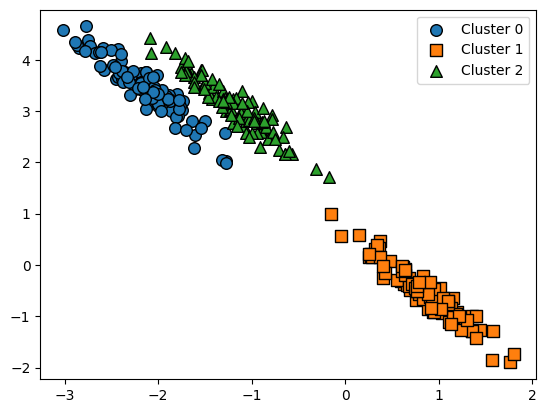

In [53]:
# gmm : n_components = 3
gmm = GaussianMixture(n_components=3,random_state=0)
gmm_label = gmm.fit(X_aniso).predict(X_aniso)
clusterDF['gmm_label']=gmm_label

# GaussianMixture : cluster_centers_ 없음, iscenter=False
visualize_cluster_plot(gmm,clusterDF,'gmm_label',iscenter=False)

In [55]:
print('## K-means Clustering ##')
print(clusterDF.groupby(['target'])['kmeans_label'].value_counts())
print('\n## Gaussian Mixture Clustering ##')
print(clusterDF.groupby(['target'])['gmm_label'].value_counts())

## K-means Clustering ##
target  kmeans_label
0       2                73
        0                27
1       1               100
2       0                86
        2                14
Name: count, dtype: int64

## Gaussian Mixture Clustering ##
target  gmm_label
0       2            100
1       1            100
2       0            100
Name: count, dtype: int64


- k-means는 Target 1만 정확히 매핑됨
- GMM은 군집과 타겟이 1:1로 잘 매핑됨 / 유연하게 잘 적용되지만 시간이 오래 걸림.


# 05. DBSCAN

## DBSCAN 적용하기 - 붓꽃 데이터 세트

In [56]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
feature_names = ['sepal_length','sepal_width','petal_length','petal_width']

irisDF = pd.DataFrame(data=iris.data,columns=feature_names)
irisDF['target']=iris.target

In [58]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.6, min_samples=8, metric='euclidean')
dbscan_labels = dbscan.fit_predict(iris.data)

irisDF['dbscan_cluster'] = dbscan_labels
irisDF['target'] = iris.target

iris_result = irisDF.groupby(['target'])['dbscan_cluster'].value_counts()
print(iris_result)

target  dbscan_cluster
0        0                49
        -1                 1
1        1                46
        -1                 4
2        1                42
        -1                 8
Name: count, dtype: int64


*** dbscan_cluster값


*   -1: noise
*   0, 1 > dbscan을 통해 군집화된 군집
*   target 값 3개 > 2개로 군집화됨. ( 효율이 떨어진다는 의미 ❌ )


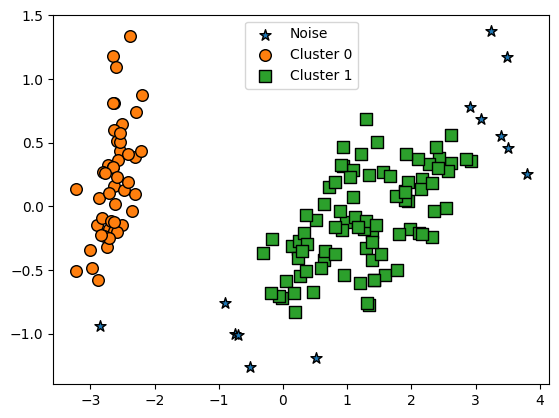

In [59]:
from sklearn.decomposition import PCA
# 2차원으로 시각화 하기위해 PCA(n_components = 2)로 피처 데이터셋 변환
pca = PCA(n_components=2, random_state=0)
pca_transformed = pca.fit_transform(iris.data)
# visualize_cluster_plot() > ftr1,ftr2 생성
irisDF['ftr1'] = pca_transformed[:,0]
irisDF['ftr2'] = pca_transformed[:,1]

visualize_cluster_plot(dbscan, irisDF, 'dbscan_cluster', iscenter=False)

🔽 eps 0.6 > 0.8 로 증가
- noise 군집(-1) 3개 밖에 없음.

target  dbscan_cluster
0        0                50
1        1                50
2        1                47
        -1                 3
Name: count, dtype: int64


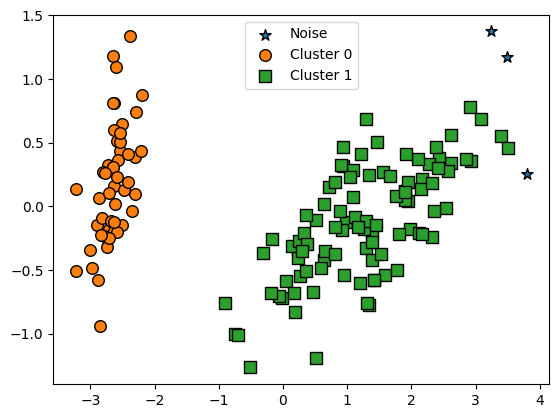

In [61]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=8, metric='euclidean')
dbscan_labels = dbscan.fit_predict(iris.data)

irisDF['dbscan_cluster'] = dbscan_labels
irisDF['target'] = iris.target

iris_result = irisDF.groupby(['target'])['dbscan_cluster'].value_counts()
print(iris_result)

visualize_cluster_plot(dbscan, irisDF, 'dbscan_cluster', iscenter=False)

🔽 eps : 0.6, min_samples : 8 > 16
- noise 🔼

target  dbscan_cluster
0        0                48
        -1                 2
1        1                44
        -1                 6
2        1                36
        -1                14
Name: count, dtype: int64


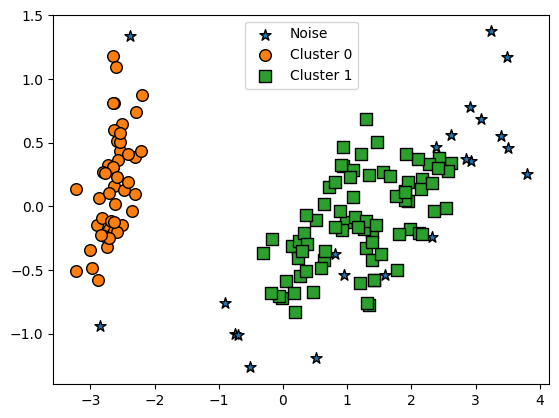

In [62]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.6, min_samples=16, metric='euclidean')
dbscan_labels = dbscan.fit_predict(iris.data)

irisDF['dbscan_cluster'] = dbscan_labels
irisDF['target'] = iris.target

iris_result = irisDF.groupby(['target'])['dbscan_cluster'].value_counts()
print(iris_result)

visualize_cluster_plot(dbscan, irisDF, 'dbscan_cluster', iscenter=False)

## DBSCAN 적용하기 - make_circles( ) 데이터세트

복잡한 기하학적 분포를 가지는 데이터 세트에서 DBSCAN과 타 알고리즘 비교
* make_circles > 도넛 2개 겹쳐 있는 데이터 세트 생성
* noise : noise 데이터 비율
* factor : 외부 원/ 내부 원 scale 비율

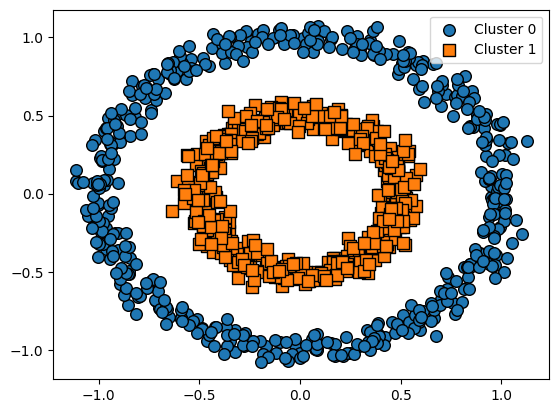

In [64]:
from sklearn.datasets import make_circles

X,y = make_circles(n_samples = 1000, shuffle = True, noise = 0.05, random_state=0, factor=0.5)
clusterDF = pd.DataFrame(data=X,columns=['ftr1','ftr2'])
clusterDF['target']=y

visualize_cluster_plot(None, clusterDF, 'target', iscenter=False)

*** K-means로 군집화

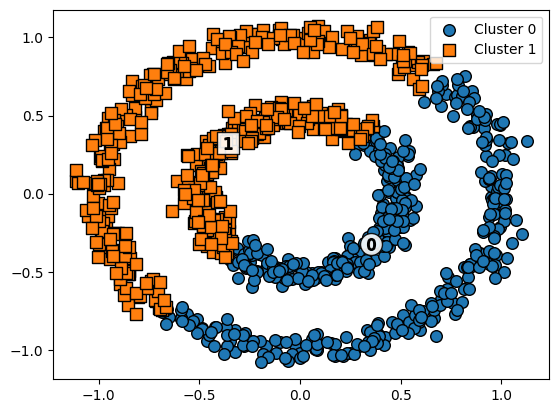

In [65]:
# k-means clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, max_iter=1000, random_state=0)
kmeans_labels = kmeans.fit_predict(X)
clusterDF['kmeans_cluster']=kmeans_labels

visualize_cluster_plot(kmeans, clusterDF,'kmeans_cluster',iscenter=True)

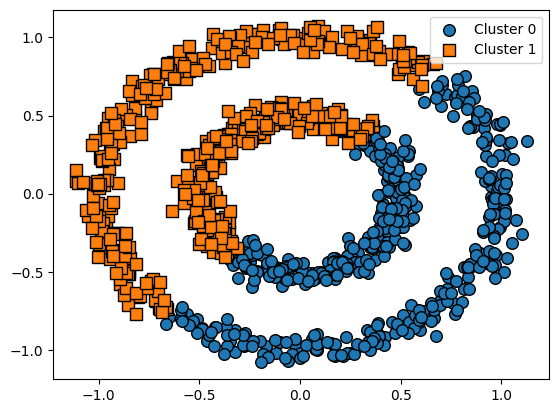

In [66]:
# GMM clustering
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2,random_state=0)
gmm_label = gmm.fit(X).predict(X)
clusterDF['gmm_cluster'] = gmm_label

visualize_cluster_plot(gmm,clusterDF,'gmm_cluster',iscenter=False)

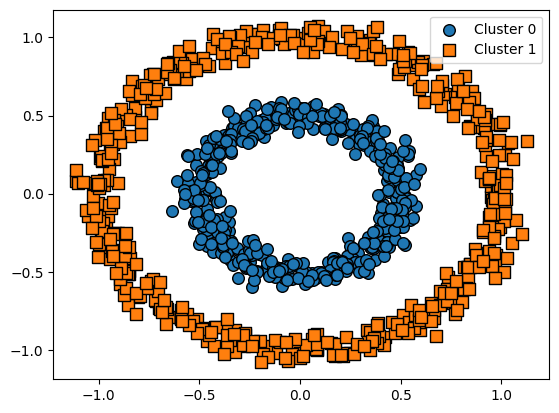

In [67]:
# DBSCAN Clustering
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.2,min_samples=10, metric='euclidean')
dbscan_labels = dbscan.fit_predict(X)
clusterDF['dbscan_cluster'] = dbscan_labels
visualize_cluster_plot(dbscan,clusterDF,'dbscan_cluster',iscenter=False)

- gmm, k-means는 원하는 대로 군집화 ❌
- DBSCAN : 의도대로 정확히 군집화

# 06. 군집화 실습 - 고객 세그먼테이션

## 고객 세그먼테이션의 정의와 기법

### 고객 세그먼테이션(Customer Segmentation)
- 다양한 기준으로 고객 분류
- CRM/마케팅 중요 기반 요소
- 목표 : 타깃 마케팅

** 이 실습에서는 RFM 기법 이용
- R (Recency) : 가장 최근 상품 구입일 ~ 오늘까지 기간
- F (Frequency) : 상품 구매 횟수
- M (Monetary Value) : 총구매


## 데이터 세트 로딩과 데이터 클렌징

In [68]:
import pandas as pd
import datetime
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

retail_df = pd.read_excel(io='/content/drive/MyDrive/Sample_data/Online Retail.xlsx')
retail_df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom




*   InvoiceNo : 주문 번호, C로 시작 - 취소된 주문

*   StockCode : 제품 코드

*   Description : 제품 설명
*   Quantity : 주문 제품 건수


*   InvoiceDate : 주문 일자


*   UnitPrice : 제품 단가

*   CustomerID : 고객 번호
*   Country : 국가명(주문 고객의 국적)





In [69]:
# 데이터 행/열수, 칼럼 dtypes, 결측치 확인
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


- 전체 데이터수 : 541909
- Customer 결측치 多 -> 결측치 제거
- 그 외 컬럼들도 오류 데이터 있음. -> 오류 데이터 제거 ( Quantity / UnitPrice < 0 )


In [70]:
retail_df = retail_df[retail_df['Quantity']>0]
retail_df = retail_df[retail_df['UnitPrice']>0]
retail_df = retail_df[retail_df['CustomerID'].notnull()]
print(retail_df.shape)
retail_df.isnull().sum()

(397884, 8)


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


** 주요 주문 고객 국적 확인
1. 영국
2. 이외 EU 여러 나라 / 영연방 국가들 ▶ 전체(397884) 중 영국이 354321, 영국 제외 국가들은 제거

In [71]:
retail_df['Country'].value_counts()[:5]

,count
Country,
United Kingdom,354321
Germany,9040
France,8341
EIRE,7236
Spain,2484


In [72]:
retail_df = retail_df[retail_df['Country']=='United Kingdom']
print(retail_df.shape)

(354321, 8)


## RFM 기반 데이터 가공

1. 주문 금액 = 'UnitPrice' * 'Quantity'
2. CustomerID : float > int

In [73]:
retail_df['sale_amount'] = retail_df['Quantity']*retail_df['UnitPrice']
retail_df['CustomerID'] = retail_df['CustomerID'].astype(int)

In [74]:
print(retail_df['CustomerID'].value_counts().head(5))
print(retail_df.groupby('CustomerID')['sale_amount'].sum().sort_values(ascending=False)[:5])

CustomerID
17841    7847
14096    5111
12748    4595
14606    2700
15311    2379
Name: count, dtype: int64
CustomerID
18102    259657.30
17450    194550.79
16446    168472.50
17511     91062.38
16029     81024.84
Name: sale_amount, dtype: float64


3. InvoiceNo + StockCode : 거의 1에 가까운 유일한 식별자 레벨이 됨

In [75]:
retail_df.groupby(['InvoiceNo','StockCode'])['InvoiceNo'].count().mean()

np.float64(1.028702077315023)

- R (Recency) : InvoiceDate칼럼의 max() 데이터 가공
- F (Frequency) : InvoiceNo 칼럼 count()
- M (Monetary Value) : sale_amount칼럼 sum()

In [77]:
# DataFrame의 groupby()의 multiple 연산을 위해 agg()이용
aggregations = {
    'InvoiceDate':'max',
    'InvoiceNo':'count',
    'sale_amount':'sum'
}
cust_df = retail_df.groupby('CustomerID').agg(aggregations)
# groupby 결과 칼럼값 > R,F,M으로 변경
cust_df = cust_df.rename(columns={'InvoiceDate':'Recency',
                                  'InvoiceNo':'Frequency',
                                  'sale_amount':'Monetary'})
cust_df = cust_df.reset_index()
cust_df.head(3)

,CustomerID,Recency,Frequency,Monetary
0,12346,2011-01-18 10:01:00,1,77183.60
1,12747,2011-12-07 14:34:00,103,4196.01
2,12748,2011-12-09 12:20:00,4595,33719.73


* Recency 칼럼 : 개별 고객당 가장 최근의 주문, ( 오늘날짜 - 최근주문일 )로 가공해줘야함

In [78]:
import datetime as dt
# 오늘 날짜 = 2011.12.10 / 데이터 중 최신 날짜 = 2011.12.9
cust_df['Recency'] = dt.datetime(2011,12,10)-cust_df['Recency']
cust_df['Recency'] = cust_df['Recency'].apply(lambda x:x.days + 1)
print('cust_df row, col 개수: ',cust_df.shape)
cust_df.head(3)

cust_df row, col 개수:  (3920, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12747,3,103,4196.01
2,12748,1,4595,33719.73


## RFM 기반 고객 세그먼테이션

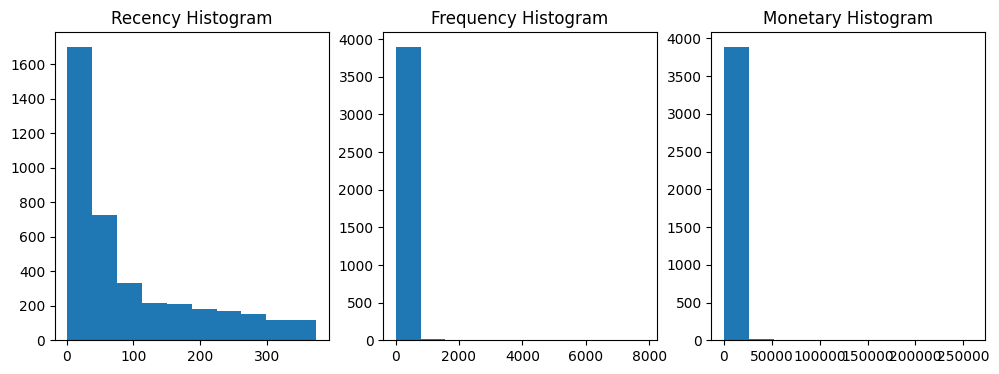

In [79]:
# RFM 각각 히스토그램 확인 >
# 왜곡된 데이터 분포도에서 군집화 수행시 발생하는 현상
fig,(ax1,ax2,ax3) = plt.subplots(figsize=(12,4),nrows=1,ncols=3)
ax1.set_title('Recency Histogram')
ax1.hist(cust_df['Recency'])

ax2.set_title('Frequency Histogram')
ax2.hist(cust_df['Frequency'])

ax3.set_title('Monetary Histogram')
ax3.hist(cust_df['Monetary'])

plt.show()

- R,F,M 모두 왜곡된 데이터 분포를 가지고 있음.

In [81]:
cust_df[['Recency','Frequency','Monetary']].describe()

,Recency,Frequency,Monetary
count,3920.000000,3920.000000,3920.000000
mean,92.742092,90.388010,1864.385601
std,99.533485,217.808385,7482.817477
min,1.000000,1.000000,3.750000
25%,18.000000,17.000000,300.280000
50%,51.000000,41.000000,652.280000
75%,143.000000,99.250000,1576.585000
max,374.000000,7847.000000,259657.300000


- R : 평균 = 92.74, 중앙값 = 51, max = 374(>>> Q3=143)
- M : 평균 = 90.3, Q_3 = 99.25, max = 7847( outliers )
- F : 평균 = 1864.3 > Q_3 = 1576.5, max = 259657.3 ( outliers )

>> StandardScaler -> kmeans

In [82]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples,silhouette_score

X_features = cust_df[['Recency','Frequency','Monetary']]
X_features_scaled = StandardScaler().fit_transform(X_features)

kmeans = KMeans(n_clusters=3,random_state=0)
labels = kmeans.fit_predict(X_features_scaled)
cust_df['cluster_label'] = labels

print('실루엣 스코어는 : {0:.3f}'.format(silhouette_score(X_features_scaled,labels)))

실루엣 스코어는 : 0.576


In [83]:
def visualize_kmeans_plot_multi(cluster_lists, X_features):

    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA
    import pandas as pd
    import numpy as np

    # plt.subplots()으로 리스트에 기재된 클러스터링 만큼의 sub figures를 가지는 axs 생성
    n_cols = len(cluster_lists)
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)

    # 입력 데이터의 FEATURE가 여러개일 경우 2차원 데이터 시각화가 어려우므로 PCA 변환하여 2차원 시각화
    pca = PCA(n_components=2)
    pca_transformed = pca.fit_transform(X_features)
    dataframe = pd.DataFrame(pca_transformed, columns=['PCA1','PCA2'])

     # 리스트에 기재된 클러스터링 갯수들을 차례로 iteration 수행하면서 KMeans 클러스터링 수행하고 시각화
    for ind, n_cluster in enumerate(cluster_lists):

        # KMeans 클러스터링으로 클러스터링 결과를 dataframe에 저장.
        clusterer = KMeans(n_clusters = n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(pca_transformed)
        dataframe['cluster']=cluster_labels

        unique_labels = np.unique(clusterer.labels_)
        markers=['o', 's', '^', 'x', '*']

        # 클러스터링 결과값 별로 scatter plot 으로 시각화
        for label in unique_labels:
            label_df = dataframe[dataframe['cluster']==label]
            if label == -1:
                cluster_legend = 'Noise'
            else :
                cluster_legend = 'Cluster '+str(label)
            axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,\
                        edgecolor='k', marker=markers[label], label=cluster_legend)

        axs[ind].set_title('Number of Cluster : '+ str(n_cluster))
        axs[ind].legend(loc='upper right')

    plt.show()

<ipython-input-83-8bec646e2207>:35: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,\
<ipython-input-83-8bec646e2207>:35: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,\


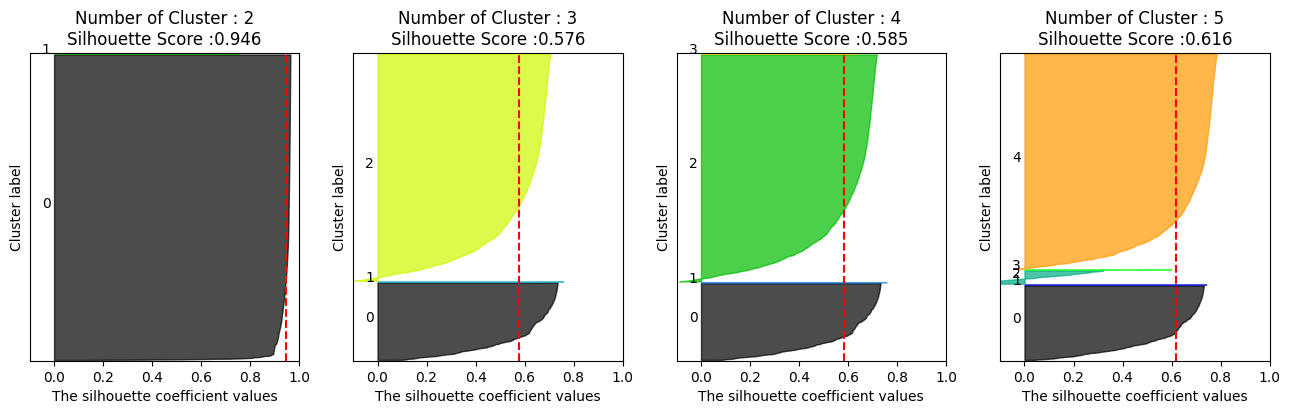

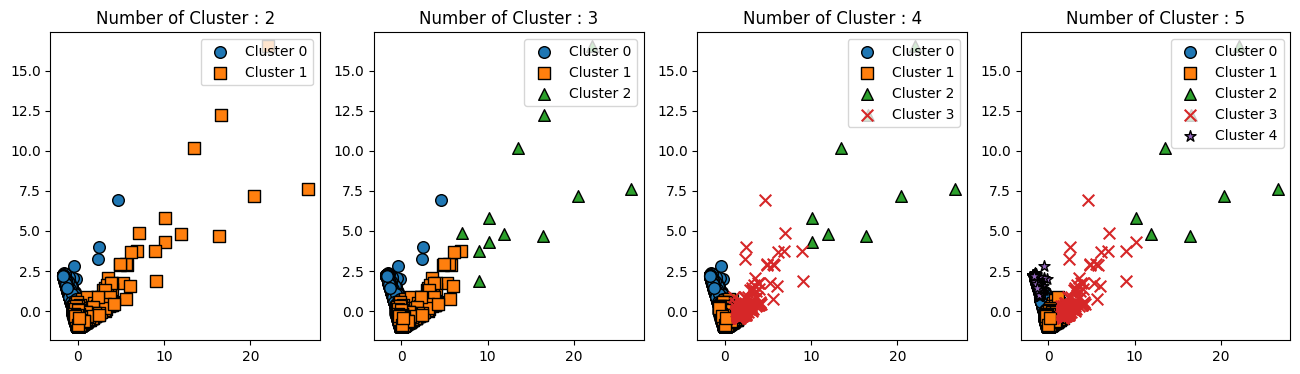

In [84]:
visualize_silhouette([2,3,4,5],X_features_scaled)
visualize_kmeans_plot_multi([2,3,4,5],X_features_scaled)



*   k = 2 : 0,1이 대충 형성됨

*   k = 3 : 0번군집 데이터수 ⬇, 광범위
*    k = 4 : 2,3번군집 데이터수 ⬇, 광범위
*    k = 5 : 2,3,4번군집 데이터수 ⬇, 광범위


➡ 거리 기반으로 데이터값이 광법위하게 퍼져 있어 군집수를 늘려도 이 군집들만 군집화됨, 의미없는 군집화 결과

왜곡을 낮추기 위해 log_transform 수행

In [85]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# R,F,M에 np.log1p()로 Log Transformation
cust_df['R_log']=np.log1p(cust_df['Recency'])
cust_df['F_log']=np.log1p(cust_df['Frequency'])
cust_df['M_log']=np.log1p(cust_df['Monetary'])

# Log_transform된 데이터에 StandardScaler 적용
X_features = cust_df[['R_log','F_log','M_log']].values
X_features_scaled = StandardScaler().fit_transform(X_features)

kmeans = KMeans(n_clusters=3, random_state=0)
labels=kmeans.fit_predict(X_features_scaled)
cust_df['cluster_label']=labels

print('실루엣 스코어는 : {0:.3f}'.format(silhouette_score(X_features_scaled,labels)))

실루엣 스코어는 : 0.303


<ipython-input-83-8bec646e2207>:35: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,\
<ipython-input-83-8bec646e2207>:35: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,\


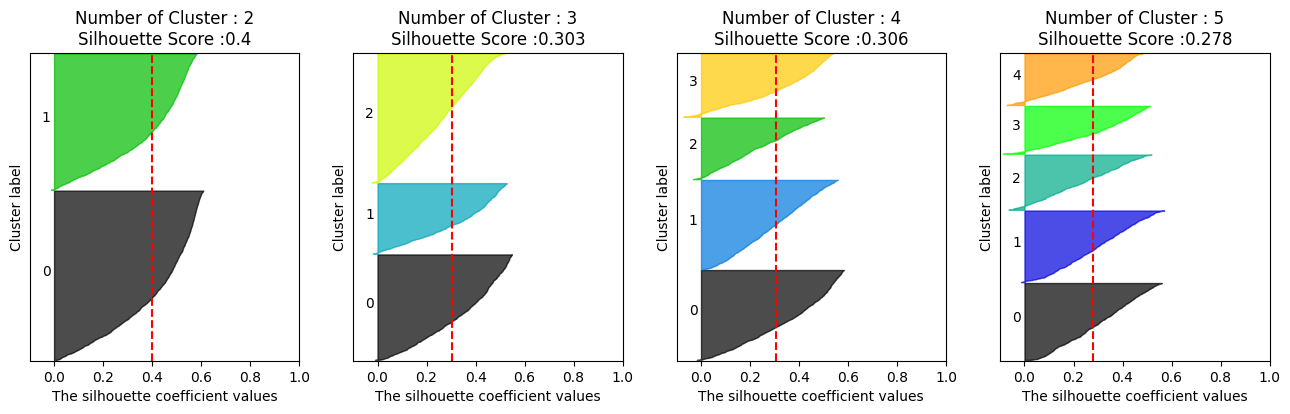

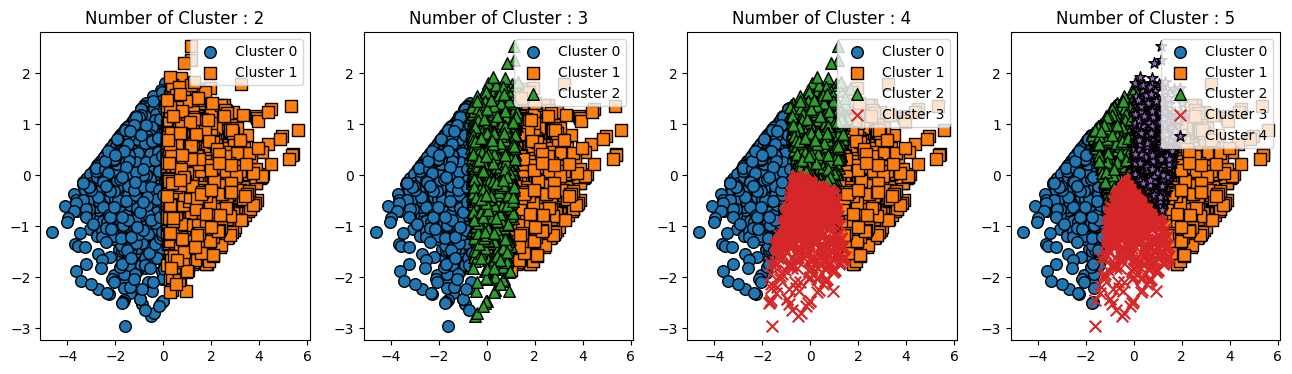

In [87]:
visualize_silhouette([2,3,4,5],X_features_scaled)
visualize_kmeans_plot_multi([2,3,4,5],X_features_scaled)

✅ log_transform 후 silhouette 점수는 떨어졌지만 군집화 구성을 시각화 해보면 더 균일하게 군집이 구성됨.